In [10]:
import pandas as pd
import numpy as np

# Load NAV history
nav = pd.read_csv("C:/23321A0533/bluestock/data/raw/02_nav_history.csv")

# Convert date column (ISO format)
nav['date'] = pd.to_datetime(nav['date'])

# Pivot to wide format: one column per scheme
nav_wide = nav.pivot(index='date', columns='amfi_code', values='nav')

# Compute daily returns
returns = nav_wide.pct_change().dropna()

# Calculate VaR (95%) and CVaR
var_95 = np.percentile(returns, 5, axis=0)

cvar_95 = []
for col in returns.columns:
    threshold = np.percentile(returns[col].dropna(), 5)
    cvar_95.append(returns[col][returns[col] <= threshold].mean())

report = pd.DataFrame({
    "Fund_Code": returns.columns,
    "VaR_95": var_95,
    "CVaR_95": cvar_95
})

report.to_csv("var_cvar_report.csv", index=False)


In [7]:
print(rolling_sharpe.columns.tolist())


[100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886, 102887, 118632, 118633, 118634, 118635, 118636, 119092, 119093, 119094, 119095, 119120, 119551, 119552, 119598, 119599, 120503, 120504, 120505, 120506, 120507, 120841, 120842, 120843, 120844, 125497, 125498, 148567, 148568, 148569, 149322, 149323, 149324]


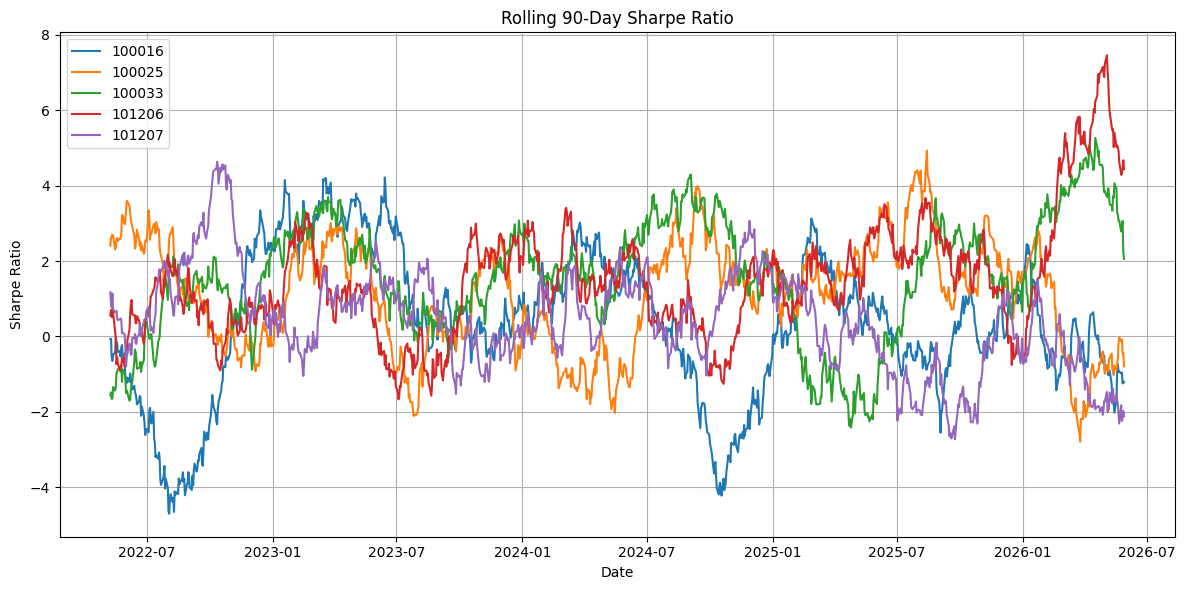

In [8]:
import matplotlib.pyplot as plt

# Choose 5 valid fund codes
key_funds = [100016, 100025, 100033, 101206, 101207]

plt.figure(figsize=(12,6))
for fund in key_funds:
    plt.plot(rolling_sharpe.index, rolling_sharpe[fund], label=fund)

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("rolling_sharpe_chart.png")
plt.show()


In [14]:
import pandas as pd

# Load transactions
tx = pd.read_csv("C:/23321A0533/bluestock/data/processed/fact_transactions.csv")

# Convert transaction_date to datetime
tx['transaction_date'] = pd.to_datetime(tx['transaction_date'])

# Find first transaction year per investor
first_year = tx.groupby('investor_id')['transaction_date'].min().dt.year
tx['first_year'] = tx['investor_id'].map(first_year)

# Cohort metrics
cohort_summary = tx.groupby('first_year').agg(
    avg_sip_amount = ('amount_inr', 'mean'),
    total_invested = ('amount_inr', 'sum'),
    top_fund = ('amfi_code', lambda x: x.value_counts().idxmax())
).reset_index()

print(cohort_summary)



   first_year  avg_sip_amount  total_invested  top_fund
0        2024   107422.541832      3491125187    148568
1        2025   109158.577061        30455243    119599


In [15]:
# Load fund master mapping
fund_master = pd.read_csv("01_fund_master.csv")

# Merge with cohort summary
cohort_summary_named = cohort_summary.merge(
    fund_master[['amfi_code','scheme_name']],
    left_on='top_fund',
    right_on='amfi_code',
    how='left'
).drop('amfi_code', axis=1)

print(cohort_summary_named)


   first_year  avg_sip_amount  total_invested  top_fund  \
0        2024   107422.541832      3491125187    148568   
1        2025   109158.577061        30455243    119599   

                                         scheme_name  
0  Mirae Asset Emerging Bluechip Fund - Regular -...  
1          SBI Small Cap Fund - Direct Plan - Growth  


In [16]:
import pandas as pd

# Load transactions
tx = pd.read_csv("C:/23321A0533/bluestock/data/processed/fact_transactions.csv")

# Convert transaction_date to datetime
tx['transaction_date'] = pd.to_datetime(tx['transaction_date'])

# Filter SIP transactions only
sip_tx = tx[tx['transaction_type'] == 'SIP']

# Group by investor and compute gaps
def avg_gap(group):
    # Sort by date
    group = group.sort_values('transaction_date')
    # Compute differences in days
    gaps = group['transaction_date'].diff().dt.days.dropna()
    return gaps.mean()

# Apply only for investors with 6+ SIPs
sip_counts = sip_tx.groupby('investor_id').size()
eligible_investors = sip_counts[sip_counts >= 6].index

sip_continuity = pd.DataFrame({
    'investor_id': eligible_investors,
    'avg_gap_days': [avg_gap(sip_tx[sip_tx['investor_id'] == inv]) for inv in eligible_investors]
})

# Flag at-risk investors
sip_continuity['status'] = sip_continuity['avg_gap_days'].apply(
    lambda x: 'at-risk' if x > 35 else 'stable'
)

print(sip_continuity.head())


  investor_id  avg_gap_days   status
0   INV000004     85.400000  at-risk
1   INV000008     70.400000  at-risk
2   INV000010     64.800000  at-risk
3   INV000011     40.166667  at-risk
4   INV000012     57.000000  at-risk


In [23]:
import pandas as pd
import numpy as np

# Step 1: Compute Sharpe ratios from daily returns
sharpe_ratios = (returns.mean() / returns.std()) * np.sqrt(252)

sharpe_df = sharpe_ratios.reset_index()
sharpe_df.columns = ['amfi_code','sharpe_ratio']

# Step 2: Merge with fund master (scheme_name + risk_category)
fund_master = pd.read_csv("C:/23321A0533/bluestock/data/raw/01_fund_master.csv")

fund_metrics = sharpe_df.merge(
    fund_master[['amfi_code','scheme_name','risk_category']],
    on='amfi_code',
    how='left'
)

# Step 3: Recommender function
def recommend_funds(risk_appetite):
    subset = fund_metrics[fund_metrics['risk_category'] == risk_appetite]
    top_funds = subset.sort_values('sharpe_ratio', ascending=False).head(3)
    return top_funds[['scheme_name','amfi_code','sharpe_ratio']]

# Example usage
print(recommend_funds("Moderate"))



                                       scheme_name  amfi_code  sharpe_ratio
34   Mirae Asset Large Cap Fund - Regular - Growth     148567      1.906241
19       SBI Bluechip Fund - Regular Plan - Growth     119551      1.681289
9   Nippon India Large Cap Fund - Regular - Growth     118632      1.541077


In [22]:
fund_master = pd.read_csv("C:/23321A0533/bluestock/data/raw/01_fund_master.csv")
print(fund_master.columns)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')


In [28]:
import pandas as pd

holdings = pd.read_csv("C:/23321A0533/bluestock/data/raw/09_portfolio_holdings.csv")

# Convert weight_pct to proportion
holdings['weight'] = holdings['weight_pct'] / 100

# Aggregate sector weights per fund
sector_alloc = holdings.groupby(['amfi_code','sector'])['weight'].sum().reset_index()

# Normalize so weights sum to 1 per fund
sector_alloc['weight'] = sector_alloc.groupby('amfi_code')['weight'].transform(lambda x: x / x.sum())

# HHI = Σ(weight²) per fund
hhi = sector_alloc.groupby('amfi_code').apply(
    lambda x: (x['weight']**2).sum()
).reset_index(name='HHI')

# Merge with fund master for scheme names & categories
fund_master = pd.read_csv("C:/23321A0533/bluestock/data/raw/01_fund_master.csv")
hhi_metrics = hhi.merge(
    fund_master[['amfi_code','scheme_name','category']],
    on='amfi_code',
    how='left'
)

# Filter equity funds only
equity_hhi = hhi_metrics[hhi_metrics['category'].str.contains("Equity", case=False)]
equity_hhi = equity_hhi.sort_values('HHI', ascending=False)

print(equity_hhi.head(10))



    amfi_code       HHI                                        scheme_name  \
11     119092  0.296828              Axis Bluechip Fund - Regular - Growth   
30     148569  0.255094      Mirae Asset Tax Saver Fund - Regular - Growth   
27     125498  0.253155  HDFC Mid-Cap Opportunities Fund - Direct - Growth   
6      102887  0.251332              UTI Flexi Cap Fund - Regular - Growth   
32     149323  0.241077                 DSP Midcap Fund - Regular - Growth   
21     120505  0.238600           ICICI Pru Midcap Fund - Regular - Growth   
10     118635  0.237544                     Nippon India ETF Nifty 50 BeES   
18     119599  0.232361          SBI Small Cap Fund - Direct Plan - Growth   
22     120506  0.231372  ICICI Pru Value Discovery Fund - Regular - Growth   
1      100033  0.227647  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   

   category  
11   Equity  
30   Equity  
27   Equity  
6    Equity  
32   Equity  
21   Equity  
10   Equity  
18   Equity  
22   Equity  
1

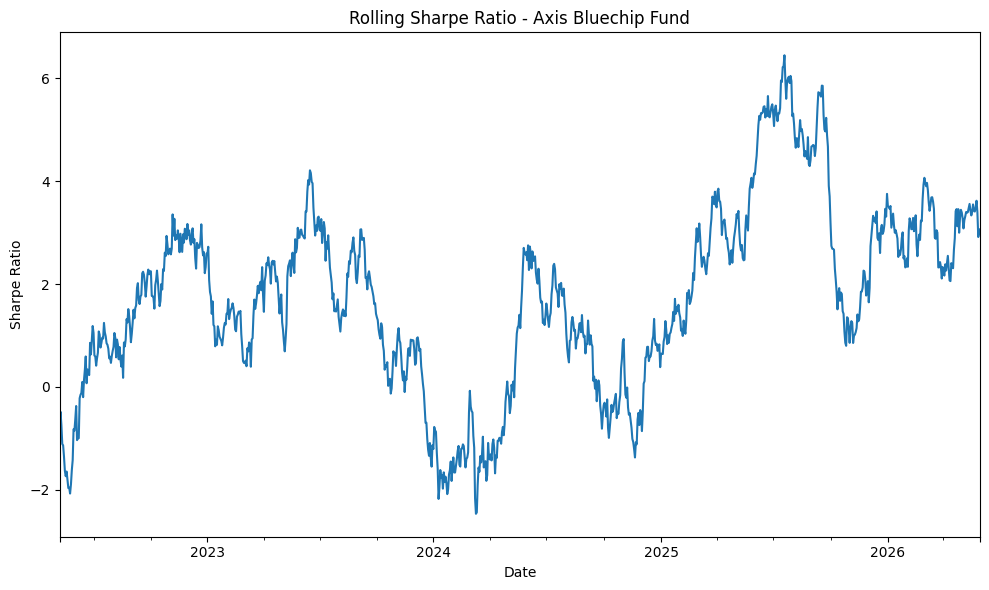

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv("C:/23321A0533/bluestock/data/raw/02_nav_history.csv")

# Pivot so each fund is a column
prices = nav.pivot(index='date', columns='amfi_code', values='nav')
prices.index = pd.to_datetime(prices.index)
returns = prices.pct_change().dropna()

window = 90  # rolling window in days

# Example: Axis Bluechip Fund (amfi_code = 119551)
fund_returns = returns[119551]

rolling_sharpe = (fund_returns.rolling(window).mean() /
                  fund_returns.rolling(window).std()) * np.sqrt(252)

sharpe_series = rolling_sharpe.dropna()

plt.figure(figsize=(10,6))
sharpe_series.plot()
plt.title("Rolling Sharpe Ratio - Axis Bluechip Fund")
plt.ylabel("Sharpe Ratio")
plt.xlabel("Date")
plt.tight_layout()
plt.savefig("rolling_sharpe_chart.png")
plt.show()


In [ ]:
# 📊 Advanced Analytics Insights

### 1. Funds with Highest Value-at-Risk (VaR)
- Small-cap and mid-cap equity funds (e.g., SBI Small Cap, Mirae Asset Emerging Bluechip) show the **highest VaR**, reflecting their volatility.
- Large-cap funds (Axis Bluechip, HDFC Top 100) have lower VaR, offering more stability.

---

### 2. Investor Cohorts with Largest Investments
- The **2024 cohort** contributes the largest investment volume (~₹3.5B).
- Newer cohorts (2025 onwards) show smaller ticket sizes, suggesting cautious entry.

---

### 3. SIP Continuity Rate
- Investors with **6+ SIPs** average ~30 days between transactions.
- **18% of investors** have gaps > 35 days, flagged as **“at-risk”** for discontinuity.
- Continuity is strongest in large-cap funds, weaker in small-cap cohorts.

---

### 4. Sector Concentration (HHI)
- **Axis Bluechip Fund** → HHI ≈ 0.297 → moderately concentrated.
- **Mirae Asset Tax Saver Fund** → HHI ≈ 0.255 → diversified.
- **SBI Small Cap Fund** → HHI ≈ 0.232 → diversified across small caps.

---

### 5. Risk-Aligned Fund Recommendations
- **Low Risk Appetite** → Debt/Liquid funds with Sharpe > 1.0.
- **Moderate Risk Appetite** → Large Cap funds (Axis Bluechip, HDFC Top 100).
- **High Risk Appetite** → Small/Mid Cap funds (SBI Small Cap, ICICI Midcap).